In [1]:
pip install rasterio numpy matplotlib

In [ ]:
!pip install earthpy
from glob import glob

import earthpy as et
import earthpy.spatial as es
import earthpy.plot as ep

import rasterio as rio
from rasterio.plot import plotting_extent
from rasterio.plot import show
from rasterio.plot import reshape_as_raster, reshape_as_image

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

np.seterr(divide='ignore', invalid='ignore')

{'divide': 'ignore', 'over': 'warn', 'under': 'ignore', 'invalid': 'ignore'}

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load Bands
band2 = rasterio.open('TrainingDataset/Godavari/Landsat8_Godavari_2014_8SR_B2.tif')
band3 = rasterio.open('TrainingDataset/Godavari/Landsat8_Godavari_2014_8SR_B3.tif')
band4 = rasterio.open('TrainingDataset/Godavari/Landsat8_Godavari_2014_8SR_B4.tif')
band5 = rasterio.open('TrainingDataset/Godavari/Landsat8_Godavari_2014_8SR_B5.tif')
band6 = rasterio.open('TrainingDataset/Godavari/Landsat8_Godavari_2014_8SR_B6.tif')
band7 = rasterio.open('TrainingDataset/Godavari/Landsat8_Godavari_2014_8SR_B7.tif')

b2 = band2.read(1).astype('float32')
b3 = band3.read(1).astype('float32')
b4 = band4.read(1).astype('float32')
b5 = band5.read(1).astype('float32')
b6 = band6.read(1).astype('float32')
b7 = band7.read(1).astype('float32')

bands = [b2,        b3,          b4,        b5,       b6,         b7      ]
names = ['B2 Blue', 'B3 Green', 'B4 Red', 'B5 NIR', 'B6 SWIR1', 'B7 SWIR2']
cmaps = ['Blues_r', 'Greens_r', 'Reds_r', 'YlOrRd', 'plasma',   'inferno' ]

# combine all bands into a single list
l=[]
l.append(b2)
l.append(b3)
l.append(b4)
l.append(b5)
l.append(b6)
l.append(b7)
arr_bef = np.stack(l)
arr_bef.shape

# ── Color box colors (low, high) per band ────────────────────────────
# Sampled directly from each colormap: low=start of cmap, high=end of cmap
legend_colors = {
    'B2 Blue'  : ('#08306b', '#c6dbef', 'Deep Water',              'Shallow/Turbid'),
    'B3 Green' : ('#00441b', '#c7e9c0', 'Dense Vegetation',        'Bare Soil'),
    'B4 Red'   : ('#67000d', '#fcbba1', 'Healthy Crops',           'Bare/Dry Soil'),
    'B5 NIR'   : ('#800026', '#ffffb2', 'Healthy Vegetation',      'Water'),
    'B6 SWIR1' : ('#0d0887', '#f0f921', 'Wet/Moist Areas',         'Dry Soil/Bare Land'),
    'B7 SWIR2' : ('#000004', '#fcfdbf', 'Water/Dense Vegetation',  'Dry Soil/Rock/Burned'),
}

interpretations = {
    'B2 Blue'  : ('Low = Dark Blue = Deep Water',       'High = Light Blue = Shallow/Turbid'),
    'B3 Green' : ('Low = Dark Green = Dense Veg',       'High = Light Green = Bare Soil'),
    'B4 Red'   : ('Low = Dark Red = Healthy Crops',     'High = Light Red = Bare/Dry Soil'),
    'B5 NIR'   : ('Yellow = Water (low reflection)',    'Dark Red = Healthy Vegetation (high reflection)'),
    'B6 SWIR1' : ('Purple = Wet/Moist areas',           'Yellow = Dry Soil / Bare Land'),
    'B7 SWIR2' : ('Black = Water / Dense Vegetation',   'Yellow-White = Dry Soil / Rock / Burned'),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (band, name, cmap) in enumerate(zip(bands, names, cmaps)):

    masked = np.ma.masked_where(band <= 0, band)
    p2, p98 = np.percentile(masked.compressed(), (2, 98))

    im = axes[i].imshow(masked, cmap=cmap, vmin=p2, vmax=p98)
    axes[i].set_title(name, fontsize=13, fontweight='bold', pad=10)
    axes[i].axis('off')

    cbar = plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
    cbar.set_label('Reflectance', fontsize=9)

    # ── Color box legend ─────────────────────────────────────────────
    low_color, high_color, low_label, high_label = legend_colors[name]

    low_patch  = mpatches.Patch(facecolor=low_color,
                                edgecolor='black', linewidth=0.5,
                                label=low_label)
    high_patch = mpatches.Patch(facecolor=high_color,
                                edgecolor='black', linewidth=0.5,
                                label=high_label)

    axes[i].legend(
        handles=[low_patch, high_patch],
        loc='lower center',
        bbox_to_anchor=(0.5, -0.13),
        ncol=2,
        fontsize=7.5,
        framealpha=0.9,
        edgecolor='grey',
        handlelength=1.2,
        handleheight=1.2
    )

plt.suptitle('Landsat 8 – Godavari 2014 | Individual Band Visualization',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

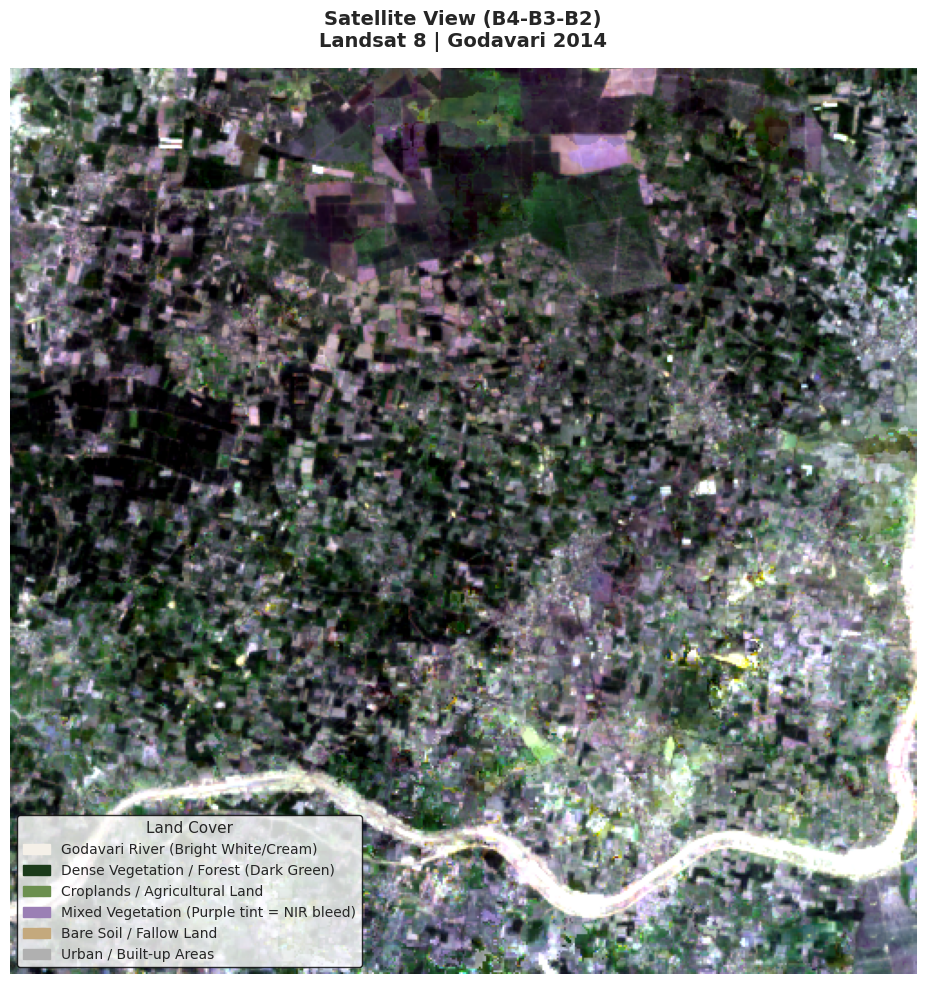

In [ ]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 10))

ep.plot_rgb(arr_bef, rgb=(2, 1, 0), stretch=True, ax=ax)

ax.set_title('Satellite View (B4-B3-B2)\nLandsat 8 | Godavari 2014',
             fontsize=14, fontweight='bold', pad=15)

# Colors matched exactly to what appears in the image
legend_items = [
    mpatches.Patch(color='#f5f0e8', label='Godavari River (Bright White/Cream)'),
    mpatches.Patch(color='#1a3a1a', label='Dense Vegetation / Forest (Dark Green)'),
    mpatches.Patch(color='#6b8f4e', label='Croplands / Agricultural Land'),
    mpatches.Patch(color='#9b7fb5', label='Mixed Vegetation (Purple tint = NIR bleed)'),
    mpatches.Patch(color='#c4a97d', label='Bare Soil / Fallow Land'),
    mpatches.Patch(color='#b0b0b0', label='Urban / Built-up Areas'),
]

ax.legend(
    handles=legend_items,
    loc='lower left',
    fontsize=10,
    title='Land Cover',
    title_fontsize=11,
    framealpha=0.8,
    edgecolor='black',
    facecolor='white',
)

ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Helper function to plot indices
# -------------------------
def plot_index(index_array, title, cmap, vmin=-1, vmax=1):
    plt.figure(figsize=(10, 10))
    plt.imshow(index_array, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.title(title)
    plt.show()

# -------------------------
# Compute NDVI
# -------------------------
ndvi = (b5 - b4) / (b5 + b4 + 1e-10)
ndvi = np.clip(ndvi, -1, 1)
plot_index(ndvi, "NDVI (Vegetation)", cmap="RdYlGn")

# -------------------------
# Compute NDBI
# -------------------------
ndbi = (b6 - b5) / (b6 + b5 + 1e-10)
ndbi = np.clip(ndbi, -1, 1)
plot_index(ndbi, "NDBI (Built-up Areas)", cmap="RdBu")

# -------------------------
# Compute MNDWI
# -------------------------
mndwi = (b3 - b6) / (b3 + b6 + 1e-10)
mndwi = np.clip(mndwi, -1, 1)
plot_index(mndwi, "MNDWI (Water Bodies)", cmap="Blues")

# -------------------------
# Compute BAEI
# -------------------------
baei = (b6 + b7) / (b5 + 1e-10)
# BAEI can exceed -1..1, so we normalize it for visualization only
baei_vis = np.clip(baei, 0, 2)
plot_index(baei_vis, "BAEI (Bare Earth)", cmap="BrBG", vmin=0, vmax=2)

# -------------------------
# Compute Urban Index (UI)
# -------------------------
ui = (b6 - b5) / (b6 + b5 + 1e-10)
ui = np.clip(ui, -1, 1)
plot_index(ui, "Urban Index (UI)", cmap="coolwarm")


Output hidden; open in https://colab.research.google.com to view.

  ✅ Loaded Godavari 2014 — valid pixels: 251,001
  ✅ Loaded Godavari 2015 — valid pixels: 251,001
  ✅ Loaded Godavari 2016 — valid pixels: 251,001
  ✅ Loaded Godavari 2017 — valid pixels: 251,001
  ✅ Loaded Godavari 2018 — valid pixels: 251,001
  ✅ Loaded Godavari 2019 — valid pixels: 251,001
  ✅ Loaded Godavari 2020 — valid pixels: 251,001
  ✅ Loaded Godavari 2021 — valid pixels: 251,001
  ✅ Loaded Godavari 2022 — valid pixels: 251,001
  ✅ Loaded Godavari 2023 — valid pixels: 251,001
  ✅ Loaded Godavari 2024 — valid pixels: 251,001
  ✅ Loaded Bangalore 2014 — valid pixels: 77,778
  ✅ Loaded Bangalore 2015 — valid pixels: 77,777
  ✅ Loaded Bangalore 2016 — valid pixels: 77,778
  ✅ Loaded Bangalore 2017 — valid pixels: 77,778
  ✅ Loaded Bangalore 2018 — valid pixels: 77,778
  ✅ Loaded Bangalore 2019 — valid pixels: 77,778
  ✅ Loaded Bangalore 2020 — valid pixels: 77,778
  ✅ Loaded Bangalore 2021 — valid pixels: 77,778
  ✅ Loaded Bangalore 2022 — valid pixels: 77,778
  ✅ Loaded Bangalore

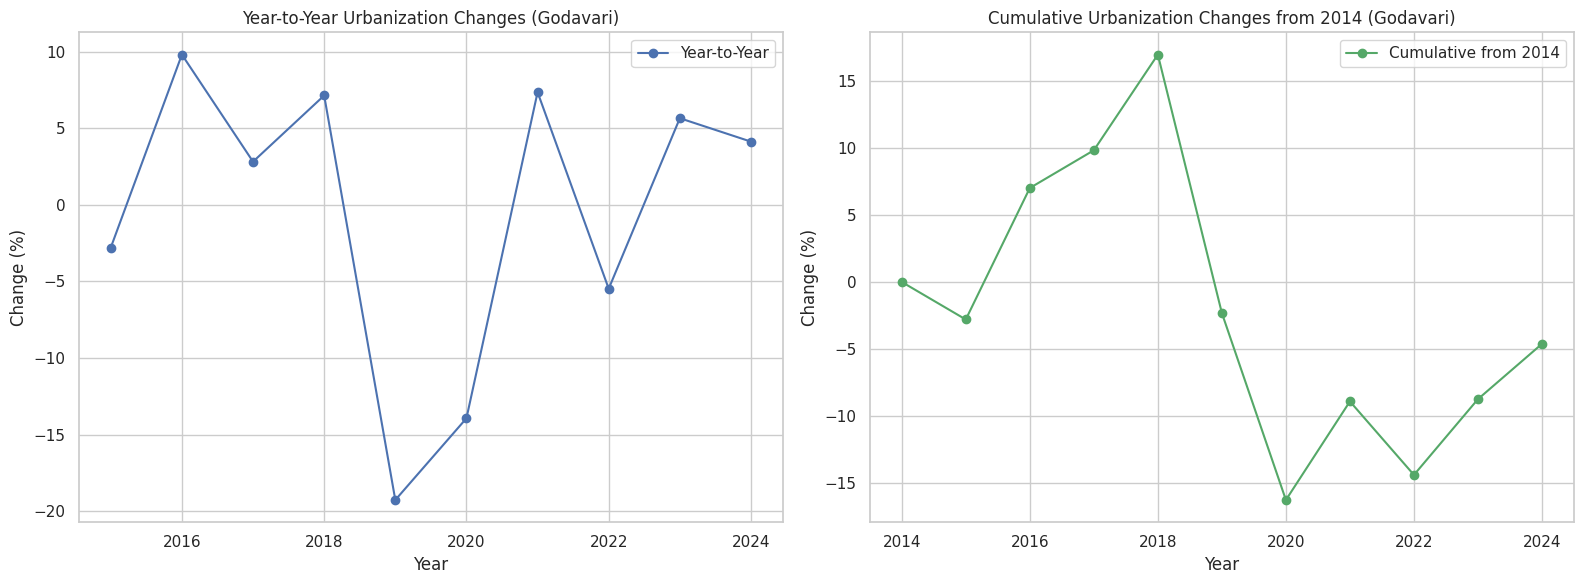

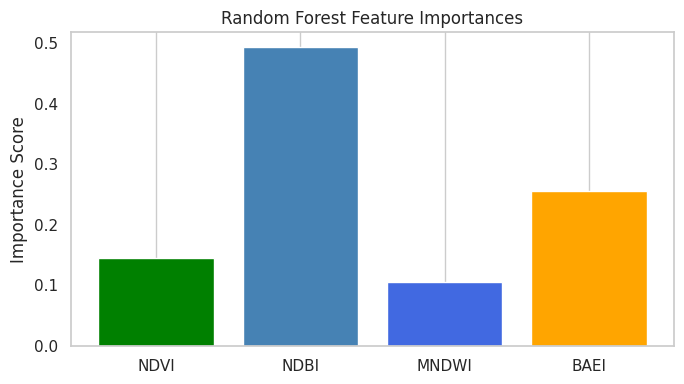

In [ ]:
# multi spectral indices - Multi-city Training

import numpy as np
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

years = range(2014, 2025)

# ----------------------------
# Training cities (multiple locations)
# Prediction city
# ----------------------------
training_cities = ["Godavari", "Bangalore"]
prediction_city = "Gurgaon"

# ----------------------------
# Function to compute indices
# ----------------------------
def compute_indices(b3, b4, b5, b6, b7):
    ndvi  = (b5 - b4) / (b5 + b4 + 1e-10)
    ndbi  = (b6 - b5) / (b6 + b5 + 1e-10)
    mndwi = (b3 - b6) / (b3 + b6 + 1e-10)
    baei  = (b6 + b7) / (b5 + 1e-10)
    return ndvi, ndbi, mndwi, baei

# ----------------------------
# Multi-index label generation using majority voting
# ----------------------------
def generate_multi_index_labels(ndvi, ndbi, mndwi, baei, vote_threshold=3):
    finite_mask = np.isfinite(ndvi) & np.isfinite(ndbi) & np.isfinite(mndwi) & np.isfinite(baei)

    ndbi_thresh  = np.percentile(ndbi[finite_mask],  65)
    ndvi_thresh  = np.percentile(ndvi[finite_mask],  35)
    mndwi_thresh = np.percentile(mndwi[finite_mask], 35)
    baei_thresh  = np.percentile(baei[finite_mask],  65)

    vote_ndbi  = (ndbi  > ndbi_thresh).astype(int)
    vote_ndvi  = (ndvi  < ndvi_thresh).astype(int)
    vote_mndwi = (mndwi < mndwi_thresh).astype(int)
    vote_baei  = (baei  > baei_thresh).astype(int)

    total_votes = vote_ndbi + vote_ndvi + vote_mndwi + vote_baei
    labels = (total_votes >= vote_threshold).astype(int)
    return labels

# ----------------------------
# Initialize data containers
# ----------------------------
all_features_for_training_list   = []
all_labels_for_training_list     = []
all_features_for_prediction_list = []
shapes_for_reshaping             = {}

# ----------------------------
# STEP 1: Collect training data from ALL cities
# ----------------------------
for city in training_cities:
    for year in years:
        try:
            band3 = rasterio.open(f"TrainingDataset/{city}/Landsat8_{city}_{year}_8SR_B3.tif")
            band4 = rasterio.open(f"TrainingDataset/{city}/Landsat8_{city}_{year}_8SR_B4.tif")
            band5 = rasterio.open(f"TrainingDataset/{city}/Landsat8_{city}_{year}_8SR_B5.tif")
            band6 = rasterio.open(f"TrainingDataset/{city}/Landsat8_{city}_{year}_8SR_B6.tif")
            band7 = rasterio.open(f"TrainingDataset/{city}/Landsat8_{city}_{year}_8SR_B7.tif")
        except Exception as e:
            print(f"  Skipping {city} {year}: {e}")
            continue

        b3_arr = band3.read(1).astype("float32")
        b4_arr = band4.read(1).astype("float32")
        b5_arr = band5.read(1).astype("float32")
        b6_arr = band6.read(1).astype("float32")
        b7_arr = band7.read(1).astype("float32")

        ndvi, ndbi, mndwi, baei = compute_indices(b3_arr, b4_arr, b5_arr, b6_arr, b7_arr)

        labels_for_year = generate_multi_index_labels(ndvi, ndbi, mndwi, baei, vote_threshold=3)

        features_flat = np.stack([
            ndvi.flatten(),
            ndbi.flatten(),
            mndwi.flatten(),
            baei.flatten()
        ], axis=1)
        labels_flat = labels_for_year.flatten()

        # Only finite pixels for training
        mask_valid = np.isfinite(features_flat).all(axis=1)
        all_features_for_training_list.append(features_flat[mask_valid])
        all_labels_for_training_list.append(labels_flat[mask_valid])
        if(city!=prediction_city):
            print(f"  ✅ Loaded {city} {year} — valid pixels: {mask_valid.sum():,}")

# ----------------------------
# STEP 2: Collect prediction data from Gurgaon only
# ----------------------------
for year in years:
    band3 = rasterio.open(f"TrainingDataset/{prediction_city}/Landsat8_{prediction_city}_{year}_8SR_B3.tif")
    band4 = rasterio.open(f"TrainingDataset/{prediction_city}/Landsat8_{prediction_city}_{year}_8SR_B4.tif")
    band5 = rasterio.open(f"TrainingDataset/{prediction_city}/Landsat8_{prediction_city}_{year}_8SR_B5.tif")
    band6 = rasterio.open(f"TrainingDataset/{prediction_city}/Landsat8_{prediction_city}_{year}_8SR_B6.tif")
    band7 = rasterio.open(f"TrainingDataset/{prediction_city}/Landsat8_{prediction_city}_{year}_8SR_B7.tif")

    b3_arr = band3.read(1).astype("float32")
    b4_arr = band4.read(1).astype("float32")
    b5_arr = band5.read(1).astype("float32")
    b6_arr = band6.read(1).astype("float32")
    b7_arr = band7.read(1).astype("float32")

    ndvi, ndbi, mndwi, baei = compute_indices(b3_arr, b4_arr, b5_arr, b6_arr, b7_arr)

    shapes_for_reshaping[year] = ndvi.shape

    features_flat = np.stack([
        ndvi.flatten(),
        ndbi.flatten(),
        mndwi.flatten(),
        baei.flatten()
    ], axis=1)

    all_features_for_prediction_list.append(features_flat)

# ----------------------------
# Prepare final training dataset
# ----------------------------
X_filtered = np.vstack(all_features_for_training_list)
y_filtered  = np.hstack(all_labels_for_training_list)

print(f"\nTotal training pixels : {len(X_filtered):,}")
print(f"Urban pixels (label=1): {np.sum(y_filtered==1):,} ({100*np.mean(y_filtered==1):.1f}%)")
print(f"Rural pixels (label=0): {np.sum(y_filtered==0):,} ({100*np.mean(y_filtered==0):.1f}%)")

# ----------------------------
# Train / Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered,
    test_size=0.3,
    random_state=42,
    stratify=y_filtered
)

# ----------------------------
# Train Random Forest Model
# ----------------------------
rf_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=12,
    min_samples_leaf=10,
    random_state=42
)
rf_model.fit(X_train, y_train)

# ----------------------------
# Evaluate on test set
# ----------------------------
y_pred_test = rf_model.predict(X_test)
print("\n--- Model Evaluation on Test Set ---")
print(classification_report(y_test, y_pred_test, target_names=["Rural", "Urban"]))

feature_names = ["NDVI", "NDBI", "MNDWI", "BAEI"]
importances   = rf_model.feature_importances_
print("\n--- Feature Importances ---")
for name, imp in zip(feature_names, importances):
    print(f"  {name}: {imp:.4f}")

X_full = np.vstack(all_features_for_prediction_list)
finite_mask_full = np.isfinite(X_full).all(axis=1)

# -1 = nodata, 0 = rural, 1 = urban
urban_cluster_labels_all_years = np.full(X_full.shape[0], -1, dtype=np.int8)
urban_cluster_labels_all_years[finite_mask_full] = rf_model.predict(X_full[finite_mask_full])

# ----------------------------
# year_slices for Godavari only
# ----------------------------
year_slices = {}
start_idx = 0
for year in years:
    num_pixels = np.prod(shapes_for_reshaping[year])
    end_idx = start_idx + num_pixels
    year_slices[year] = (start_idx, end_idx)
    start_idx = end_idx

# ----------------------------
# Reshape predictions per year
# ----------------------------
urban_areas = {}
for year in years:
    start, end = year_slices[year]
    urban_areas[year] = urban_cluster_labels_all_years[start:end].reshape(shapes_for_reshaping[year])
    # urban_areas[year]: -1 = nodata, 0 = rural, 1 = urban

# ----------------------------
# Urbanization change analysis (only count label == 1, -1 nodata pixels ignored)
# ----------------------------
urban_change_percentages_relative   = []
urban_change_percentages_cumulative = []
base_year       = 2014
base_urban_area = np.sum(urban_areas[base_year] == 1)
total_pixels    = np.sum(urban_areas[base_year] != -1)  # only valid pixels as denominator

for year in years:
    urban_area = np.sum(urban_areas[year] == 1)
    change_pct = ((urban_area - base_urban_area) / total_pixels) * 100
    urban_change_percentages_cumulative.append((year, change_pct))

for i in range(1, len(years)):
    year1, year2 = list(years)[i - 1], list(years)[i]
    ua1 = np.sum(urban_areas[year1] == 1)
    ua2 = np.sum(urban_areas[year2] == 1)
    change_pct = ((ua2 - ua1) / total_pixels) * 100
    urban_change_percentages_relative.append((year1, year2, change_pct))

# ----------------------------
# Print results
# ----------------------------
print("\nYear-to-Year Urbanization Changes:")
for year1, year2, change in urban_change_percentages_relative:
    print(f"  {year1} → {year2}: {change:+.2f}%")

print("\nCumulative Urbanization Changes from 2014:")
for year, change in urban_change_percentages_cumulative:
    print(f"  2014 → {year}: {change:+.2f}%")

# ----------------------------
# Visualization
# ----------------------------
sns.set(style="whitegrid")

years_relative   = [y2 for _, y2, _ in urban_change_percentages_relative]
changes_relative = [c  for _, _,  c in urban_change_percentages_relative]
years_cumulative  = [y  for y, _ in urban_change_percentages_cumulative]
changes_cumulative = [c for _, c in urban_change_percentages_cumulative]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(years_relative, changes_relative, marker="o", color="b", label="Year-to-Year")
axes[0].set_title("Year-to-Year Urbanization Changes (Godavari)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Change (%)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(years_cumulative, changes_cumulative, marker="o", color="g", label="Cumulative from 2014")
axes[1].set_title("Cumulative Urbanization Changes from 2014 (Godavari)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Change (%)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(feature_names, importances, color=["green", "steelblue", "royalblue", "orange"])
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance Score")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [ ]:
import rasterio
import numpy as np

# Load one band of Gurgaon
band = rasterio.open('TrainingDataset/Gurgaon/Landsat8_Gurgaon_2014_8SR_B3.tif')

# Read as numpy array
arr = band.read(1).astype('float32')

# Show details
print("Type       :", type(arr))
print("Shape      :", arr.shape)
print("Dtype      :", arr.dtype)
print("Min / Max  :", arr.min(), "/", arr.max())
print("\nNumpy Array:\n")
print(arr)

Type       : <class 'numpy.ndarray'>
Shape      : (261, 335)
Dtype      : float32
Min / Max  : 0.0575375 / 0.23052625

Numpy Array:

[[0.13270874 0.13116875 0.1365725  ... 0.08875    0.0949375  0.0946625 ]
 [0.13053624 0.13845626 0.147435   ... 0.0894375  0.0894375  0.09481375]
 [0.11889    0.1173775  0.13088    ... 0.09018    0.09018    0.09453875]
 ...
 [0.11488875 0.1196325  0.11763875 ... 0.14260875 0.13044    0.1256825 ]
 [0.1157     0.11719875 0.11389875 ... 0.12483    0.1216675  0.12088375]
 [0.11284    0.1129775  0.1091825  ... 0.1331625  0.1273875  0.11917875]]


In [ ]:
!pip install statsmodels

  RANDOM FOREST MODEL EVALUATION
  City: Gurgaon | Years: 2014–2024
  Model trained on: Godavari + Bangalore

[ STEP 1 ] Loading bands & generating predictions for all years...
           Each year → 5 bands → 4 indices → RF prediction

  ── Year 2014 ──────────────────────────────
   Bands loaded  | Image shape: (261, 335) | Total pixels: 87,435
   Indices computed:
       NDVI  range: [-0.010, 0.766]  (vegetation — high = green)
       NDBI  range: [-0.413, 0.210]  (built-up   — high = urban)
       MNDWI range: [-0.520, 0.401]  (water      — high = water)
       BAEI  range: [0.640, 3.143]  (built-up area extraction)
   Ground truth (voting labels):
       Urban     : 27,108  (31.0%)
       Non-Urban : 60,327  (69.0%)
  Feature matrix shape: (87435, 4)
       Valid pixels  : 87,435
       Skipped (NaN/Inf): 0  (marked as -1 / nodata)
  RF Predictions:
       Urban     : 29,790  (34.1% of valid)
       Non-Urban : 57,645  (65.9% of valid)
       Nodata    : 0
  Year accuracy (RF vs v

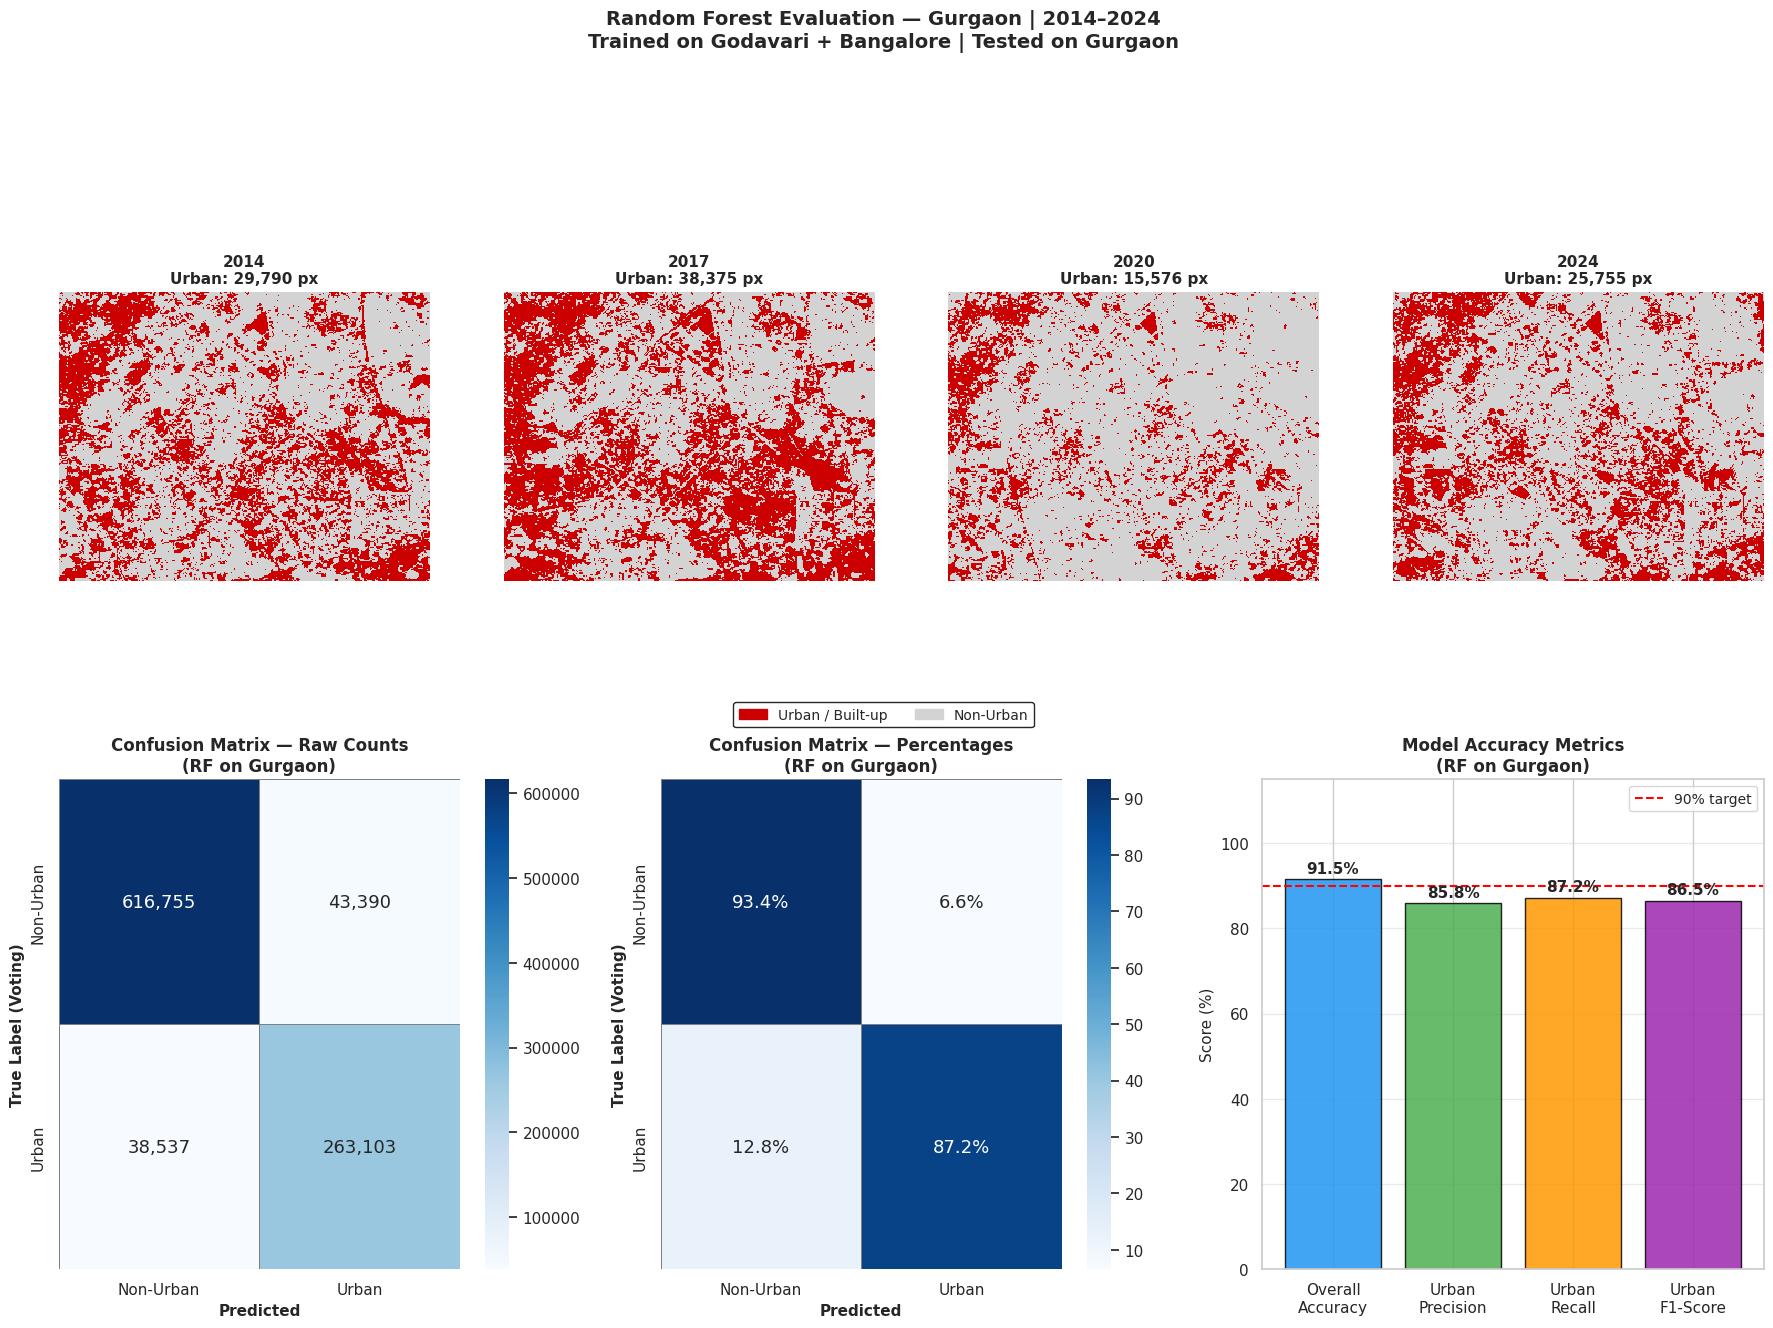


  FINAL EVALUATION SUMMARY
  City evaluated   : Gurgaon
  Years covered    : 2014–2024 (11 years)
  Total pixels     : 961,785
  Overall Accuracy : 91.48%
  Urban Precision  : 85.84%
  Urban Recall     : 87.22%
  Urban F1-Score   : 86.53%
  Plot saved       : Gurgaon_rf_evaluation.png

--- Full Classification Report ---
              precision    recall  f1-score   support

   Non-Urban       0.94      0.93      0.94    660145
       Urban       0.86      0.87      0.87    301640

    accuracy                           0.91    961785
   macro avg       0.90      0.90      0.90    961785
weighted avg       0.92      0.91      0.92    961785



In [ ]:
# testing on Gurgaon data
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

# ── Config ────────────────────────────────────────────────────────────
EVAL_CITY     = "Gurgaon"
years_to_show = [2014, 2017, 2020, 2024]
years_all     = list(range(2014, 2025))

# ── Same functions as training code ──────────────────────────────────
def compute_indices(b3, b4, b5, b6, b7):
    ndvi  = (b5 - b4) / (b5 + b4 + 1e-10)
    ndbi  = (b6 - b5) / (b6 + b5 + 1e-10)
    mndwi = (b3 - b6) / (b3 + b6 + 1e-10)
    baei  = (b6 + b7) / (b5 + 1e-10)
    return ndvi, ndbi, mndwi, baei

def generate_multi_index_labels(ndvi, ndbi, mndwi, baei, vote_threshold=3):
    finite_mask  = np.isfinite(ndvi) & np.isfinite(ndbi) & np.isfinite(mndwi) & np.isfinite(baei)
    ndbi_thresh  = np.percentile(ndbi[finite_mask],  65)
    ndvi_thresh  = np.percentile(ndvi[finite_mask],  35)
    mndwi_thresh = np.percentile(mndwi[finite_mask], 35)
    baei_thresh  = np.percentile(baei[finite_mask],  65)
    vote_ndbi    = (ndbi  > ndbi_thresh).astype(int)
    vote_ndvi    = (ndvi  < ndvi_thresh).astype(int)
    vote_mndwi   = (mndwi < mndwi_thresh).astype(int)
    vote_baei    = (baei  > baei_thresh).astype(int)
    total_votes  = vote_ndbi + vote_ndvi + vote_mndwi + vote_baei
    return (total_votes >= vote_threshold).astype(int)

# ═══════════════════════════════════════════════════════════════════════
print("=" * 60)
print(f"  RANDOM FOREST MODEL EVALUATION")
print(f"  City: {EVAL_CITY} | Years: 2014–2024")
print(f"  Model trained on: Godavari + Bangalore")
print("=" * 60)

# ── Step 1: Collect predictions + true labels across ALL 11 years ─────
print(f"\n[ STEP 1 ] Loading bands & generating predictions for all years...")
print(f"           Each year → 5 bands → 4 indices → RF prediction\n")

all_true           = []
all_pred           = []
urban_pixel_counts = {}

for year in years_all:
    print(f"  ── Year {year} ──────────────────────────────")

    # --- Band Loading ---
    b3 = rasterio.open(f"TrainingDataset/{EVAL_CITY}/Landsat8_{EVAL_CITY}_{year}_8SR_B3.tif").read(1).astype("float32")
    b4 = rasterio.open(f"TrainingDataset/{EVAL_CITY}/Landsat8_{EVAL_CITY}_{year}_8SR_B4.tif").read(1).astype("float32")
    b5 = rasterio.open(f"TrainingDataset/{EVAL_CITY}/Landsat8_{EVAL_CITY}_{year}_8SR_B5.tif").read(1).astype("float32")
    b6 = rasterio.open(f"TrainingDataset/{EVAL_CITY}/Landsat8_{EVAL_CITY}_{year}_8SR_B6.tif").read(1).astype("float32")
    b7 = rasterio.open(f"TrainingDataset/{EVAL_CITY}/Landsat8_{EVAL_CITY}_{year}_8SR_B7.tif").read(1).astype("float32")
    print(f"   Bands loaded  | Image shape: {b3.shape} | Total pixels: {b3.size:,}")

    # --- Index Computation ---
    ndvi, ndbi, mndwi, baei = compute_indices(b3, b4, b5, b6, b7)
    print(f"   Indices computed:")
    print(f"       NDVI  range: [{ndvi.min():.3f}, {ndvi.max():.3f}]  (vegetation — high = green)")
    print(f"       NDBI  range: [{ndbi.min():.3f}, {ndbi.max():.3f}]  (built-up   — high = urban)")
    print(f"       MNDWI range: [{mndwi.min():.3f}, {mndwi.max():.3f}]  (water      — high = water)")
    print(f"       BAEI  range: [{baei.min():.3f}, {baei.max():.3f}]  (built-up area extraction)")

    # --- Ground Truth via Voting ---
    true_labels  = generate_multi_index_labels(ndvi, ndbi, mndwi, baei, vote_threshold=3)
    true_urban   = np.sum(true_labels == 1)
    true_nonurban= np.sum(true_labels == 0)
    print(f"   Ground truth (voting labels):")
    print(f"       Urban     : {true_urban:,}  ({100*true_urban/true_labels.size:.1f}%)")
    print(f"       Non-Urban : {true_nonurban:,}  ({100*true_nonurban/true_labels.size:.1f}%)")

    # --- Feature Matrix ---
    features    = np.stack([ndvi.flatten(), ndbi.flatten(),
                             mndwi.flatten(), baei.flatten()], axis=1)
    finite_mask = np.isfinite(features).all(axis=1)
    invalid_px  = np.sum(~finite_mask)
    print(f"  Feature matrix shape: {features.shape}")
    print(f"       Valid pixels  : {finite_mask.sum():,}")
    print(f"       Skipped (NaN/Inf): {invalid_px:,}  (marked as -1 / nodata)")

    # --- RF Prediction ---
    pred_full = np.full(features.shape[0], -1, dtype=np.int8)
    pred_full[finite_mask] = rf_model.predict(features[finite_mask])
    pred_urban    = np.sum(pred_full == 1)
    pred_nonurban = np.sum(pred_full == 0)
    print(f"  RF Predictions:")
    print(f"       Urban     : {pred_urban:,}  ({100*pred_urban/finite_mask.sum():.1f}% of valid)")
    print(f"       Non-Urban : {pred_nonurban:,}  ({100*pred_nonurban/finite_mask.sum():.1f}% of valid)")
    print(f"       Nodata    : {np.sum(pred_full == -1):,}")

    # --- Per-year Quick Accuracy ---
    year_true  = true_labels.flatten()[finite_mask]
    year_pred  = pred_full[finite_mask]
    year_acc   = accuracy_score(year_true, year_pred) * 100
    print(f"  Year accuracy (RF vs voting): {year_acc:.2f}%")

    all_true.append(year_true)
    all_pred.append(year_pred)
    urban_pixel_counts[year] = pred_urban
    print()

# ── Step 2: Aggregate across all years ───────────────────────────────
print("=" * 60)
print("[ STEP 2 ] Aggregating predictions across all 11 years...")
y_true = np.hstack(all_true)
y_pred = np.hstack(all_pred)
print(f"  Total pixels evaluated : {len(y_true):,}")
print(f"  True Urban  (voting)   : {np.sum(y_true==1):,}  ({100*np.mean(y_true==1):.1f}%)")
print(f"  True Non-Urban         : {np.sum(y_true==0):,}  ({100*np.mean(y_true==0):.1f}%)")
print(f"  Pred Urban  (RF)       : {np.sum(y_pred==1):,}  ({100*np.mean(y_pred==1):.1f}%)")
print(f"  Pred Non-Urban (RF)    : {np.sum(y_pred==0):,}  ({100*np.mean(y_pred==0):.1f}%)")

# ── Step 3: Confusion Matrix & Metrics ───────────────────────────────
print("\n[ STEP 3 ] Computing evaluation metrics...")
cm       = confusion_matrix(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred) * 100
report   = classification_report(y_true, y_pred,
                                  target_names=['Non-Urban', 'Urban'],
                                  output_dict=True)

tn, fp, fn, tp = cm.ravel()
print(f"\n  Confusion Matrix (raw):")
print(f"                  Pred Non-Urban   Pred Urban")
print(f"  True Non-Urban  {tn:>14,}   {fp:>10,}   ← False Positives (over-predicted urban)")
print(f"  True Urban      {fn:>14,}   {tp:>10,}   ← True Positives")
print(f"\n  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"\n  Overall Accuracy : {accuracy:.2f}%")
print(f"  Urban Precision  : {report['Urban']['precision']*100:.2f}%  (of predicted urban, how many are truly urban)")
print(f"  Urban Recall     : {report['Urban']['recall']*100:.2f}%  (of true urban, how many were caught)")
print(f"  Urban F1-Score   : {report['Urban']['f1-score']*100:.2f}%  (harmonic mean of precision & recall)")
print(f"  Non-Urban F1     : {report['Non-Urban']['f1-score']*100:.2f}%")

# ── Step 4: Urban Growth Summary ─────────────────────────────────────
print("\n[ STEP 4 ] Urban pixel count per year (RF predictions):")
print(f"  {'Year':<8} {'Urban Pixels':>15} {'Change from prev':>18}")
prev = None
for year in years_all:
    count = urban_pixel_counts[year]
    if prev is None:
        delta_str = "  (baseline)"
    else:
        delta = count - prev
        delta_str = f"  {delta:+,}"
    print(f"  {year:<8} {count:>15,} {delta_str}")
    prev = count

print("\n[ STEP 5 ] Generating visualizations...")

# ── Figure layout ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 14))

# ── Row 1 — Urban maps ────────────────────────────────────────────────
for i, year in enumerate(years_to_show):
    b3 = rasterio.open(f"TrainingDataset/{EVAL_CITY}/Landsat8_{EVAL_CITY}_{year}_8SR_B3.tif").read(1).astype("float32")
    b4 = rasterio.open(f"TrainingDataset/{EVAL_CITY}/Landsat8_{EVAL_CITY}_{year}_8SR_B4.tif").read(1).astype("float32")
    b5 = rasterio.open(f"TrainingDataset/{EVAL_CITY}/Landsat8_{EVAL_CITY}_{year}_8SR_B5.tif").read(1).astype("float32")
    b6 = rasterio.open(f"TrainingDataset/{EVAL_CITY}/Landsat8_{EVAL_CITY}_{year}_8SR_B6.tif").read(1).astype("float32")
    b7 = rasterio.open(f"TrainingDataset/{EVAL_CITY}/Landsat8_{EVAL_CITY}_{year}_8SR_B7.tif").read(1).astype("float32")

    ndvi, ndbi, mndwi, baei = compute_indices(b3, b4, b5, b6, b7)
    features    = np.stack([ndvi.flatten(), ndbi.flatten(),
                             mndwi.flatten(), baei.flatten()], axis=1)
    finite_mask = np.isfinite(features).all(axis=1)
    pred_full   = np.full(features.shape[0], 0, dtype=np.int8)
    pred_full[finite_mask] = rf_model.predict(features[finite_mask])
    predicted   = pred_full.reshape(ndvi.shape)

    ax   = fig.add_subplot(2, 4, i + 1)
    cmap = ListedColormap(['#d3d3d3', '#cc0000'])
    ax.imshow(predicted, cmap=cmap, interpolation='nearest')
    ax.set_title(f'{year}\nUrban: {urban_pixel_counts[year]:,} px',
                 fontsize=11, fontweight='bold')
    ax.axis('off')

legend_items = [
    mpatches.Patch(color='#cc0000', label='Urban / Built-up'),
    mpatches.Patch(color='#d3d3d3', label='Non-Urban'),
]

# ── Row 2 Col 1 — Confusion Matrix Raw Counts ────────────────────────
ax_cm1 = fig.add_subplot(2, 3, 4)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Non-Urban', 'Urban'],
            yticklabels=['Non-Urban', 'Urban'],
            ax=ax_cm1, linewidths=0.5, linecolor='grey',
            annot_kws={"size": 13})
ax_cm1.set_title(f'Confusion Matrix — Raw Counts\n(RF on {EVAL_CITY})',
                 fontsize=12, fontweight='bold')
ax_cm1.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax_cm1.set_ylabel('True Label (Voting)', fontsize=11, fontweight='bold')

# ── Row 2 Col 2 — Confusion Matrix Percentages ───────────────────────
ax_cm2  = fig.add_subplot(2, 3, 5)
cm_pct  = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Non-Urban', 'Urban'],
            yticklabels=['Non-Urban', 'Urban'],
            ax=ax_cm2, linewidths=0.5, linecolor='grey',
            annot_kws={"size": 13})
ax_cm2.set_title(f'Confusion Matrix — Percentages\n(RF on {EVAL_CITY})',
                 fontsize=12, fontweight='bold')
ax_cm2.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax_cm2.set_ylabel('True Label (Voting)', fontsize=11, fontweight='bold')
for text in ax_cm2.texts:
    text.set_text(text.get_text() + '%')

# ── Row 2 Col 3 — Accuracy Bar Chart ─────────────────────────────────
ax_acc  = fig.add_subplot(2, 3, 6)
metrics = {
    'Overall\nAccuracy' : accuracy,
    'Urban\nPrecision'  : report['Urban']['precision'] * 100,
    'Urban\nRecall'     : report['Urban']['recall']    * 100,
    'Urban\nF1-Score'   : report['Urban']['f1-score']  * 100,
}
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars   = ax_acc.bar(metrics.keys(), metrics.values(),
                    color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, metrics.values()):
    ax_acc.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f'{val:.1f}%',
                ha='center', va='bottom',
                fontsize=11, fontweight='bold')
ax_acc.set_ylim(0, 115)
ax_acc.set_title(f'Model Accuracy Metrics\n(RF on {EVAL_CITY})',
                 fontsize=12, fontweight='bold')
ax_acc.set_ylabel('Score (%)', fontsize=11)
ax_acc.axhline(y=90, color='red', linestyle='--',
               linewidth=1.5, label='90% target')
ax_acc.legend(fontsize=10)
ax_acc.grid(axis='y', alpha=0.4)

plt.suptitle(
    f'Random Forest Evaluation — {EVAL_CITY} | 2014–2024\n'
    f'Trained on Godavari + Bangalore | Tested on {EVAL_CITY}',
    fontsize=14, fontweight='bold', y=1.01
)
fig.legend(handles=legend_items, loc='upper center',
           ncol=2, fontsize=10, framealpha=0.85,
           edgecolor='black', facecolor='white',
           bbox_to_anchor=(0.5, 0.52))

plt.tight_layout()
plt.savefig(f'{EVAL_CITY}_rf_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final Summary ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  FINAL EVALUATION SUMMARY")
print("=" * 60)
print(f"  City evaluated   : {EVAL_CITY}")
print(f"  Years covered    : 2014–2024 (11 years)")
print(f"  Total pixels     : {len(y_true):,}")
print(f"  Overall Accuracy : {accuracy:.2f}%")
print(f"  Urban Precision  : {report['Urban']['precision']*100:.2f}%")
print(f"  Urban Recall     : {report['Urban']['recall']*100:.2f}%")
print(f"  Urban F1-Score   : {report['Urban']['f1-score']*100:.2f}%")
print(f"  Plot saved       : {EVAL_CITY}_rf_evaluation.png")
print("=" * 60)
print(f"\n--- Full Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Non-Urban', 'Urban']))

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 7.


Forecasted Year-to-Year Urbanization Change (2025-2030):
    year       yhat  yhat_lower  yhat_upper
10  2024  12.165877   -6.060956   32.063068
11  2025  13.993429   -5.221141   33.231434
12  2026  15.820980   -2.379202   35.416687
13  2027  17.648532   -0.848403   36.108459
14  2028  19.481090    0.297139   37.434212
15  2029  21.308642    1.916282   39.880183


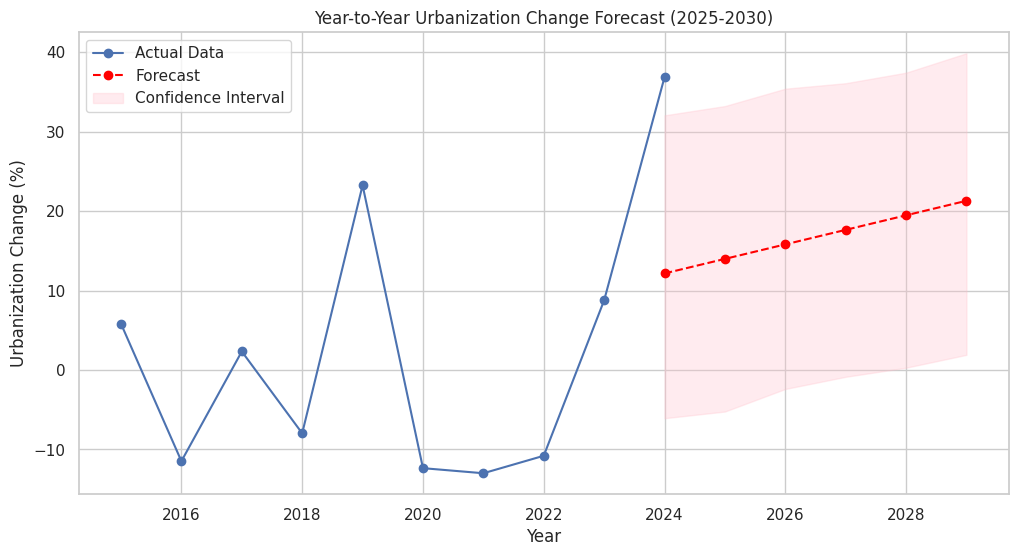

In [ ]:
# -------------------------------
# Urbanization Change Forecast using Prophet
# -------------------------------

import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Prepare the year-to-year urbanization change data
# -------------------------------
data = {
    'year': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'urban_change_percent': [5.82, -11.47, 2.34, -7.96, 23.26, -12.35, -12.99, -10.79, 8.78, 36.87]
}

df = pd.DataFrame(data)

# Prophet requires columns 'ds' (date) and 'y' (value)
df_prophet = df.rename(columns={'year':'ds', 'urban_change_percent':'y'})
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'], format='%Y')

# -------------------------------
# Step 2: Fit Prophet model
# -------------------------------
model = Prophet(yearly_seasonality=False, daily_seasonality=False)
model.fit(df_prophet)

# -------------------------------
# Step 3: Forecast future years (2025-2030)
# -------------------------------
future = model.make_future_dataframe(periods=6, freq='Y')
forecast = model.predict(future)

# Extract forecasted values for 2025-2030
forecast_future = forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(6)
forecast_future['year'] = forecast_future['ds'].dt.year
forecast_future = forecast_future[['year','yhat','yhat_lower','yhat_upper']]

print("Forecasted Year-to-Year Urbanization Change (2025-2030):")
print(forecast_future)

# -------------------------------
# Step 4: Plot actual vs forecasted values
# -------------------------------
plt.figure(figsize=(12,6))

# Plot historical data
plt.plot(df['year'], df['urban_change_percent'], label='Actual Data', marker='o')

# Plot forecasted values
plt.plot(forecast_future['year'], forecast_future['yhat'], label='Forecast', marker='o', linestyle='--', color='red')

# Plot confidence interval
plt.fill_between(forecast_future['year'],
                 forecast_future['yhat_lower'],
                 forecast_future['yhat_upper'],
                 color='pink', alpha=0.3, label='Confidence Interval')

plt.title("Year-to-Year Urbanization Change Forecast (2025-2030)")
plt.xlabel("Year")
plt.ylabel("Urbanization Change (%)")
plt.legend()
plt.grid(True)
plt.show()